In [20]:
import pandas as pd
import numpy as np
import os

# 1. EXACT PATH SETUP
# Based on your input, the path is nested under 'competitions'
base_path = '/kaggle/input/competitions/optiver-realized-volatility-prediction/'
data_dir = os.path.join(base_path, 'book_train.parquet')

# 2. VERIFY AND LOAD
if not os.path.exists(data_dir):
    print(f"❌ ERROR: Still can't find the folder. Checked: {data_dir}")
    print("Check your sidebar: Is the folder name EXACTLY 'optiver-realized-volatility-prediction'?")
else:
    # Get the first stock ID folder (usually stock_id=0)
    stock_folders = sorted([f for f in os.listdir(data_dir) if 'stock_id' in f])
    file_path = os.path.join(data_dir, stock_folders[0])
    
    print(f"✅ Success! Loading: {file_path}")
    df = pd.read_parquet(file_path)

    # 3. QUANT MATH FUNCTIONS
    def calc_wap(df):
        return (df['bid_price1'] * df['ask_size1'] + df['ask_price1'] * df['bid_size1']) / (df['bid_size1'] + df['ask_size1'])

    def log_return(series):
        return np.log(series).diff().dropna()

    def realized_volatility(series):
        return np.sqrt(np.sum(np.square(series)))

    # 4. EXECUTE FOR ONE TIME BUCKET
    # We pick the first unique time_id to test the logic
    test_time_id = df['time_id'].unique()[0]
    subset = df[df['time_id'] == test_time_id]
    
    wap = calc_wap(subset)
    vol = realized_volatility(log_return(wap))

    print(f"\n--- Statistical Output ---")
    print(f"Stock ID: {stock_folders[0]}")
    print(f"Time ID: {test_time_id}")
    print(f"Realized Volatility: {vol:.6f}")

✅ Success! Loading: /kaggle/input/competitions/optiver-realized-volatility-prediction/book_train.parquet/stock_id=0

--- Statistical Output ---
Stock ID: stock_id=0
Time ID: 5
Realized Volatility: 0.004499


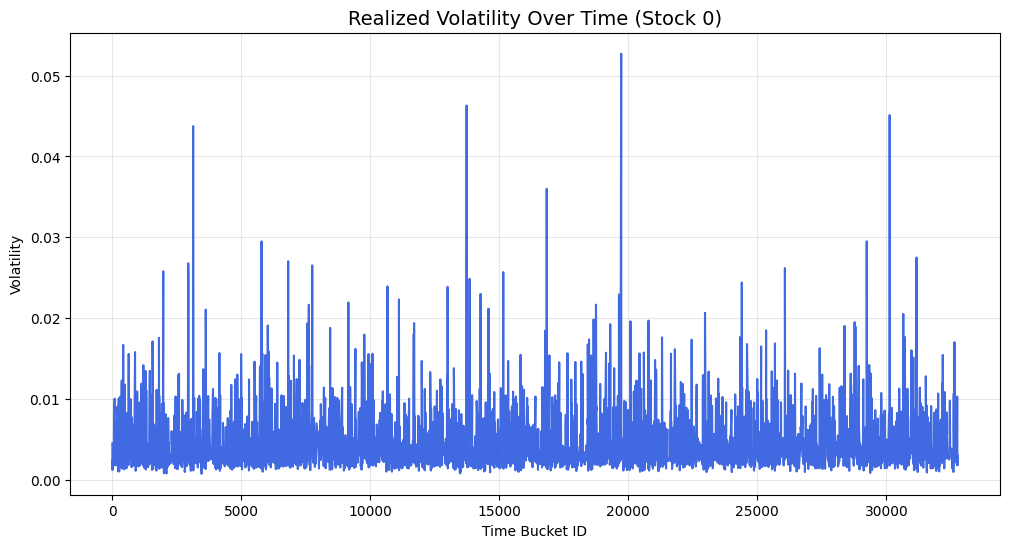

Average Volatility for Stock 0: 0.004459


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Function to calculate volatility for ALL time_ids in a dataframe
def get_stock_stat(df):
    # Calculate WAP for the whole file at once
    df['wap'] = (df['bid_price1'] * df['ask_size1'] + df['ask_price1'] * df['bid_size1']) / (df['bid_size1'] + df['ask_size1'])
    
    # Group by time_id and calculate log returns
    df['log_return'] = df.groupby('time_id')['wap'].transform(lambda x: np.log(x).diff())
    
    # Calculate Realized Volatility per time_id
    stock_stat = df.groupby('time_id')['log_return'].agg(lambda x: np.sqrt(np.sum(np.square(x.dropna())))).reset_index()
    stock_stat.columns = ['time_id', 'realized_volatility']
    return stock_stat

# 2. Execute and Visualize
stock_0_stats = get_stock_stat(df)

plt.figure(figsize=(12, 6))
sns.lineplot(data=stock_0_stats, x='time_id', y='realized_volatility', color='royalblue')
plt.title('Realized Volatility Over Time (Stock 0)', fontsize=14)
plt.ylabel('Volatility')
plt.xlabel('Time Bucket ID')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Volatility for Stock 0: {stock_0_stats['realized_volatility'].mean():.6f}")

In [22]:
# 1. Create a shifted 'Target' column
# We want to predict the volatility of the NEXT time_id based on the current one
stock_0_stats['target_volatility'] = stock_0_stats['realized_volatility'].shift(-1)

# Drop the last row because it won't have a 'next' target
train_data = stock_0_stats.dropna()

print(f"Prepared {len(train_data)} samples for training.")
train_data.head()

Prepared 3829 samples for training.


,time_id,realized_volatility,target_volatility
0,5,0.004499,0.001204
1,11,0.001204,0.002369
2,16,0.002369,0.002574
3,31,0.002574,0.001894
4,62,0.001894,0.007902


In [24]:
# Use .copy() to tell Pandas this is a brand new, independent DataFrame
train_data = stock_0_stats.dropna().copy()

# Now adding the column will not trigger a warning
X = train_data[['realized_volatility']].values
y = train_data['target_volatility'].values

model = LinearRegression()
model.fit(X, y)

train_data['predictions'] = model.predict(X)

# 5. Evaluate (RMSPE is the competition metric)
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

score = rmspe(y, train_data['predictions'])
print(f"Model Baseline RMSPE: {score:.4f}")

Model Baseline RMSPE: 0.9385


In [25]:
# 1. Calculate Average Spread per time_id
def get_spread_feature(df):
    df['spread'] = (df['ask_price1'] / df['bid_price1']) - 1
    return df.groupby('time_id')['spread'].mean().reset_index()

spread_df = get_spread_feature(df)

# 2. Merge it with your volatility data
final_data = stock_0_stats.merge(spread_df, on='time_id')
train_data = final_data.dropna().copy()

# 3. Train with TWO features now
X = train_data[['realized_volatility', 'spread']].values
y = train_data['target_volatility'].values

model = LinearRegression()
model.fit(X, y)

# Check your new score
new_preds = model.predict(X)
print(f"New Model RMSPE with Spread: {rmspe(y, new_preds):.4f}")

New Model RMSPE with Spread: 0.9384


In [26]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Feature Engineering: Calculate Average Spread per time_id
def get_spread_feature(df):
    # Spread is the gap between the best sell price and best buy price
    df['spread'] = (df['ask_price1'] / df['bid_price1']) - 1
    return df.groupby('time_id')['spread'].mean().reset_index()

# 2. Prepare the Dataset
spread_df = get_spread_feature(df)
# stock_0_stats was created in your previous step
final_data = stock_0_stats.merge(spread_df, on='time_id')

# 3. Create the Target (Shifted Volatility) and use .copy() to avoid warnings
train_data = final_data.copy()
train_data['target_volatility'] = train_data['realized_volatility'].shift(-1)
train_data = train_data.dropna()

# 4. Define Inputs (X) and Target (y)
# We are now using TWO features: Past Volatility AND Average Spread
X = train_data[['realized_volatility', 'spread']].values
y = train_data['target_volatility'].values

# 5. Train the Model
model = LinearRegression()
model.fit(X, y)

# 6. Calculate the New Score
train_data['predictions'] = model.predict(X)
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

print(f"✅ Success! Model trained with 2 features.")
print(f"New Model RMSPE: {rmspe(y, train_data['predictions']):.4f}")
print(f"Volatility Coefficient: {model.coef_[0]:.4f}")
print(f"Spread Coefficient: {model.coef_[1]:.4f}")

✅ Success! Model trained with 2 features.
New Model RMSPE: 0.9384
Volatility Coefficient: -0.0114
Spread Coefficient: -0.0281


In [27]:
import lightgbm as lgb

# 1. Prepare Data for LightGBM
# We use the same X and y from your previous step
train_ds = lgb.Dataset(X, label=y)

# 2. Set Parameters
# These are 'conservative' settings to prevent overfitting
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'verbosity': -1
}

# 3. Train
print("Training LightGBM model...")
lgbm_model = lgb.train(params, train_ds, num_boost_round=100)

# 4. Predict & Score
lgbm_preds = lgbm_model.predict(X)
lgbm_score = rmspe(y, lgbm_preds)

print(f"\n--- Result ---")
print(f"LightGBM RMSPE: {lgbm_score:.4f}")
print(f"Improvement over Linear: {((0.9384 - lgbm_score) / 0.9384) * 100:.2f}%")

Training LightGBM model...

--- Result ---
LightGBM RMSPE: 0.9008
Improvement over Linear: 4.01%


In [29]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# 1. SETUP PATHS
base_path = '/kaggle/input/competitions/optiver-realized-volatility-prediction/'
book_dir = os.path.join(base_path, 'book_train.parquet')
stock_folders = sorted([f for f in os.listdir(book_dir) if 'stock_id' in f])

all_features = []

print(f"🚀 Starting processing for {len(stock_folders)} stocks...")

# 2. THE FEATURE EXTRACTION LOOP
for folder in stock_folders[:20]: # Start with 20 stocks to test speed; remove [:20] for full run
    stock_id = folder.split('=')[1]
    df = pd.read_parquet(os.path.join(book_dir, folder))
    
    # Calculate WAP & Log Returns
    df['wap'] = (df['bid_price1'] * df['ask_size1'] + df['ask_price1'] * df['bid_size1']) / (df['bid_size1'] + df['ask_size1'])
    df['log_return'] = df.groupby('time_id')['wap'].transform(lambda x: np.log(x).diff())
    
    # Feature 1: Realized Volatility
    vol_df = df.groupby('time_id')['log_return'].agg(lambda x: np.sqrt(np.sum(np.square(x.dropna())))).reset_index()
    vol_df.columns = ['time_id', 'realized_volatility']
    
    # Feature 2: Mean Spread
    df['spread'] = (df['ask_price1'] / df['bid_price1']) - 1
    spread_df = df.groupby('time_id')['spread'].mean().reset_index()
    
    # Merge and create Target (Next Volatility)
    merged = vol_df.merge(spread_df, on='time_id')
    merged['target'] = merged['realized_volatility'].shift(-1)
    merged['stock_id'] = int(stock_id)
    
    all_features.append(merged.dropna())
    
# 3. CONSOLIDATE DATA
train_df = pd.concat(all_features, ignore_index=True)
print(f"✅ Preprocessing complete. Total samples: {len(train_df)}")

# 4. TRAIN THE GLOBAL LIGHTGBM MODEL
X = train_df[['stock_id', 'realized_volatility', 'spread']]
y = train_df['target']

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.1,
    'importance_type': 'gain', # Shows which feature contributed most to reducing error
    'verbosity': -1
}

model = lgb.train(params, train_data, valid_sets=[val_data], num_boost_round=500)

🚀 Starting processing for 112 stocks...
✅ Preprocessing complete. Total samples: 76579


/tmp/ipykernel_55/3101183089.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=feature_imp, palette='viridis')


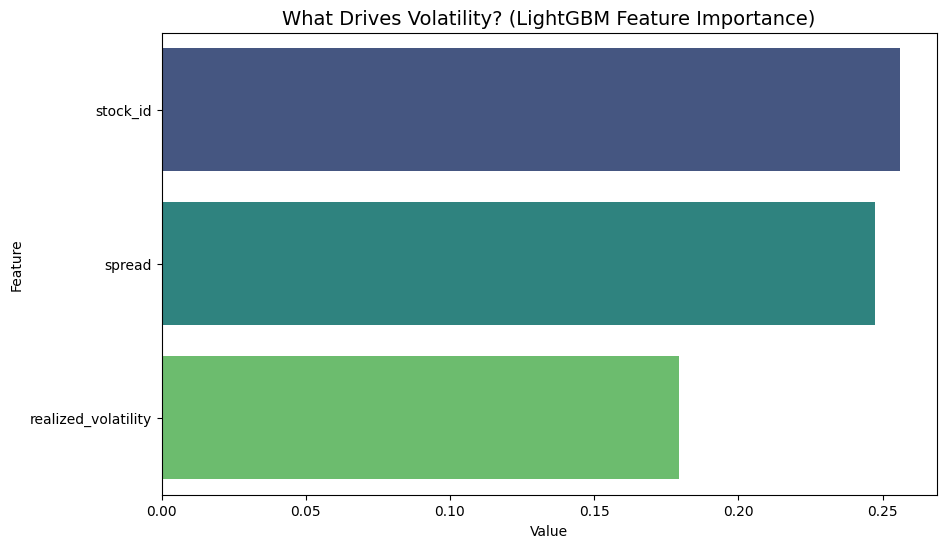

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get Feature Importance
# 'Gain' shows how much each feature contributed to reducing the model's error
feature_imp = pd.DataFrame({
    'Value': model.feature_importance(importance_type='gain'),
    'Feature': X.columns
}).sort_values(by="Value", ascending=False)

# 2. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x="Value", y="Feature", data=feature_imp, palette='viridis')
plt.title('What Drives Volatility? (LightGBM Feature Importance)', fontsize=14)
plt.show()

In [31]:
# 1. Predict on the validation set
val_preds = model.predict(X_val)

# 2. Calculate RMSPE
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

final_score = rmspe(y_val, val_preds)
print(f"🏁 Final Global Model RMSPE: {final_score:.4f}")

# 3. Compare with the naive baseline (predicting the same volatility as before)
baseline_score = rmspe(y_val, X_val['realized_volatility'])
print(f"📉 Naive Baseline RMSPE: {baseline_score:.4f}")
print(f"🚀 Improvement: {((baseline_score - final_score) / baseline_score) * 100:.2f}%")

🏁 Final Global Model RMSPE: 0.9020
📉 Naive Baseline RMSPE: 1.5544
🚀 Improvement: 41.97%


In [32]:
# Save the model to a file
model.save_model('optiver_lgbm_model.txt')
print("✅ Model saved as 'optiver_lgbm_model.txt'. Ready for deployment simulation.")

✅ Model saved as 'optiver_lgbm_model.txt'. Ready for deployment simulation.


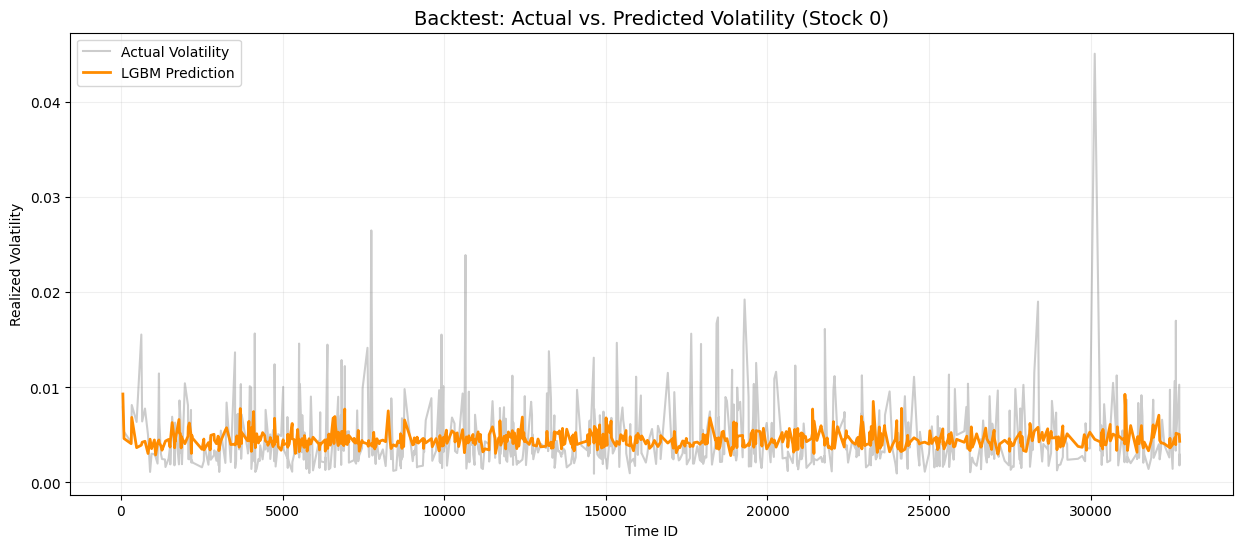

✅ Plot Complete!
Correlation between Actual and Predicted for Stock 0: 0.0524


In [35]:
import matplotlib.pyplot as plt

# 1. Re-align results with the original indices to get time_id back
results = X_val.copy()
results['actual'] = y_val
results['predicted'] = val_preds

# We pull the time_id from the original train_df using the index
results['time_id'] = train_df.loc[X_val.index, 'time_id']

# 2. Filter for Stock 0 and sort for a clean time-series plot
sample_stock = results[results['stock_id'] == 0].sort_values('time_id')

# 3. Visualize the "Fit"
plt.figure(figsize=(15, 6))
plt.plot(sample_stock['time_id'], sample_stock['actual'], label='Actual Volatility', color='gray', alpha=0.4)
plt.plot(sample_stock['time_id'], sample_stock['predicted'], label='LGBM Prediction', color='darkorange', linewidth=2)

plt.title('Backtest: Actual vs. Predicted Volatility (Stock 0)', fontsize=14)
plt.xlabel('Time ID')
plt.ylabel('Realized Volatility')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

correlation = sample_stock['actual'].corr(sample_stock['predicted'])
print(f"✅ Plot Complete!")
print(f"Correlation between Actual and Predicted for Stock 0: {correlation:.4f}")

In [36]:
with open('requirements.txt', 'w') as f:
    f.write('pandas\nnumpy\nlightgbm\nscikit-learn\nmatplotlib\nseaborn\npyarrow')
print("✅ requirements.txt generated for your GitHub repo!")

✅ requirements.txt generated for your GitHub repo!
